## Using LLM to extract answers script

Author: Sahana Kowshik

Date: 05/07/2025

In [1]:
import os
os.environ['HF_HOME'] = '/projectnb/vkolagrp/skowshik/.cache/'
import torch
import torch.nn.functional as F
import argparse
import pandas as pd
import numpy as np
import torch.distributed as dist
import json
import warnings
import random
import time
import string
warnings.filterwarnings("ignore")
import re

from tqdm import tqdm
from datetime import timedelta
from collections import OrderedDict
from transformers import AutoTokenizer, AutoModel
from vllm import LLM, SamplingParams
os.environ['VLLM_SKIP_P2P_CHECK'] = "1"

INFO 05-08 16:24:51 [__init__.py:239] Automatically detected platform cuda.


In [2]:
# model_id = 'Qwen/Qwen2.5-14B-Instruct'
model_id = 'Qwen/Qwen3-32B'
n_devices = 4
max_model_len = 5000

In [3]:
# data = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-04T134012_1b22e7e417a94d74/qwen3b_adrd_cog_status_output.csv")

In [3]:
tokenizer = AutoTokenizer.from_pretrained(model_id, padding_side='left')

In [4]:
data = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/training_data_grpo/train_summary.csv")

In [6]:
# dropped = data[data["ID"] == "NACC711803"]

In [8]:
# dropped.to_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/training_data_grpo/dropped.csv", index=False)

In [5]:
max_len = 0
len_2k = []
for i, row in data.iterrows():
    cur_len = len(tokenizer.encode(row["visit_summary"]))
    max_len = max(max_len, cur_len)
    if cur_len == 2000:
        len_2k.append(i)

In [6]:
max_len

1351

In [7]:
len_2k

[]

In [11]:
data.head()

,ID,patient_summary,diag_summary,question,options,ground_truth,Q_TYPE,visit_summary
0,NACC529204,"{\n ""Subject Demographics"": {\n ""Liv...","{\n ""Clinician Judgment of Symptoms"": {\n ...","Based on the clinical data, identify the neuro...",A. Alzheimer's disease neuropathology (AD)\nB....,H,Neuropath,The subject is a 100-year-old right-handed Whi...
1,NACC834497,"{\n ""Subject Demographics"": {\n ""Liv...","{\n ""Clinician Judgment of Symptoms"": {\n ...","Based on the clinical data, identify the neuro...",A. Alzheimer's disease neuropathology (AD)\nB....,C,Neuropath,The patient is an 88-year-old male who resides...
2,NACC029705,"{\n ""Subject Demographics"": {\n ""Liv...","{\n ""Clinician Judgment of Symptoms"": {\n ...","Based on the details provided, identify if the...",A. Yes\nB. No,B,Amyloid PET,"The patient is a 76-year-old left-handed, marr..."
3,NACC396023,"{\n ""Subject Demographics"": {\n ""Liv...","{\n ""Clinician Judgment of Symptoms"": {\n ...","Based on the patient's data, identify the appr...",A: Amnestic MCI- single domain\nB: Amnestic MC...,E,MCI subtype,The patient is an 81-year-old right-handed mal...
4,NACC362586,"{\n ""Subject Demographics"": {\n ""Liv...","{\n ""Clinician Judgment of Symptoms"": {\n ...","From the information available, determine the ...",A: Normal Cognition (NC)\nB: Mild Cognitive Im...,A,Cognitive status,"The patient is a 69-year-old left-handed, Engl..."


In [12]:
print(data.iloc[10120]['visit_summary'])

The patient is a 94-year-old White female who resides in a private residence and is right-handed. She is widowed, has completed 12 years of education, and requires some assistance with basic activities. The patient came to the Alzheimer's Disease Center primarily to participate in a research study, and the referral was made by a non-professional contact, specifically an aide. She is currently taking seven medications, including an anticoagulant (ApiXaban), a diuretic, a lipid-lowering medication, an antidepressant, an antihypertensive, and a beta-blocker. 

From a family history perspective, there is no reported cognitive impairment in the patient’s father or mother; however, there is a report of cognitive impairment in at least one first-degree family member. On the Neuropsychiatric Inventory Questionnaire (NPI-Q), the patient exhibited several behavioral and psychological symptoms. Specifically, she experienced nighttime behaviors and depression or dysphoria in the past month, both r

In [5]:
def load_model(model_id, n_devices, max_model_len):
    """Load VLLM model and Huggingface tokenizer."""
    llm = LLM(
        model=model_id,
        tokenizer=model_id,
        tensor_parallel_size=n_devices,
        gpu_memory_utilization=0.9,
        max_model_len=max_model_len,
        enable_lora=False,
        distributed_executor_backend='mp',
    )
    
    tokenizer = AutoTokenizer.from_pretrained(model_id, padding_side='left')
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        
    return llm, tokenizer

In [6]:
llm, tokenizer = load_model(model_id, n_devices, max_model_len)

INFO 05-08 16:17:08 [config.py:717] This model supports multiple tasks: {'score', 'reward', 'embed', 'classify', 'generate'}. Defaulting to 'generate'.
INFO 05-08 16:17:08 [config.py:2003] Chunked prefill is enabled with max_num_batched_tokens=16384.
INFO 05-08 16:17:10 [core.py:58] Initializing a V1 LLM engine (v0.8.5.post1) with config: model='Qwen/Qwen3-32B', speculative_config=None, tokenizer='Qwen/Qwen3-32B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=5000, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=4, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='auto', reasoning_backend=None), observability_config=ObservabilityConfig(show_hidden_metrics=False, otlp_traces_endpoint=None, coll

(VllmWorker rank=3 pid=2432207) Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1474c2d2e710>>
(VllmWorker rank=3 pid=2432207) Traceback (most recent call last):
(VllmWorker rank=3 pid=2432207)   File "/projectnb/vkolagrp/projects/adrd_foundation_model/envs/fmadrd/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
(VllmWorker rank=3 pid=2432207)     def _clean_thread_parent_frames(
(VllmWorker rank=3 pid=2432207) 
(VllmWorker rank=3 pid=2432207)   File "/projectnb/vkolagrp/projects/adrd_foundation_model/envs/fmadrd/lib/python3.11/site-packages/vllm/v1/executor/multiproc_executor.py", line 398, in signal_handler
(VllmWorker rank=3 pid=2432207)     raise SystemExit()
(VllmWorker rank=3 pid=2432207) SystemExit: 
(VllmWorker rank=2 pid=2432206) Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x

ERROR 05-08 16:17:16 [core.py:396] EngineCore failed to start.
ERROR 05-08 16:17:16 [core.py:396] Traceback (most recent call last):
ERROR 05-08 16:17:16 [core.py:396]   File "/projectnb/vkolagrp/projects/adrd_foundation_model/envs/fmadrd/lib/python3.11/site-packages/vllm/v1/engine/core.py", line 387, in run_engine_core
ERROR 05-08 16:17:16 [core.py:396]     engine_core = EngineCoreProc(*args, **kwargs)
ERROR 05-08 16:17:16 [core.py:396]                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ERROR 05-08 16:17:16 [core.py:396]   File "/projectnb/vkolagrp/projects/adrd_foundation_model/envs/fmadrd/lib/python3.11/site-packages/vllm/v1/engine/core.py", line 329, in __init__
ERROR 05-08 16:17:16 [core.py:396]     super().__init__(vllm_config, executor_class, log_stats,
ERROR 05-08 16:17:16 [core.py:396]   File "/projectnb/vkolagrp/projects/adrd_foundation_model/envs/fmadrd/lib/python3.11/site-packages/vllm/v1/engine/core.py", line 64, in __init__
ERROR 05-08 16:17:16 [core.py:396]     self.model

Process EngineCore_0:
Traceback (most recent call last):
  File "/projectnb/vkolagrp/projects/adrd_foundation_model/envs/fmadrd/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/projectnb/vkolagrp/projects/adrd_foundation_model/envs/fmadrd/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/projectnb/vkolagrp/projects/adrd_foundation_model/envs/fmadrd/lib/python3.11/site-packages/vllm/v1/engine/core.py", line 400, in run_engine_core
    raise e
  File "/projectnb/vkolagrp/projects/adrd_foundation_model/envs/fmadrd/lib/python3.11/site-packages/vllm/v1/engine/core.py", line 387, in run_engine_core
    engine_core = EngineCoreProc(*args, **kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/projectnb/vkolagrp/projects/adrd_foundation_model/envs/fmadrd/lib/python3.11/site-packages/vllm/v1/engine/core.py", line 329, in __init__
    super().__init__(vllm_config, executor_c

RuntimeError: Engine core initialization failed. See root cause above.

In [ ]:
def get_vllm_summary(llm, tokenizer, messages, max_new_tokens=3000):
    """This is a function to generate LLAMA summaries using vllm https://github.com/vllm-project/vllm

    Args:
        llm: LLM object
        tokenizer: Huggingface tokenizer
        input_texts (List): A list of input texts / prompts
        system_msg (str): system message for the LLAMA prompt

    Returns:
        List: A list of generated responses
    """
    
    # return "Answer"
    

    prompts = []
    responses = []
    
    for message in messages:
        input_ids = tokenizer.apply_chat_template(
            message,
            add_generation_prompt=True,
            tokenize=False,
            continue_final_message=False,
            enable_thinking=False
            # return_tensors="pt"
        )
        
        prompts.append(input_ids)
    
    # https://github.com/vllm-project/vllm/blob/main/vllm/sampling_params.py#L38-L66
    sampling_params = SamplingParams(
        temperature=0.7,
        top_p=0.8,
        top_k=20,
        min_p=0,
        max_tokens=max_new_tokens,
        # frequency_penalty=0.5,
        # stop=stop_tokens
    )
    
    completions = llm.generate(
        prompts=prompts,
        sampling_params=sampling_params,
    )
    
    for i, output in enumerate(completions):
        temp_gen = output.outputs[0].text
        responses.append(temp_gen)
        
    # print('Successfully finished generating', len(prompts), 'samples!')
    
    return responses

In [ ]:
PATIENT_SUMMARY_PROMPT = """You will receive patient data between <data> and </data> tags. Summarize the patient information provided without making any assumptions or conclusions. Include important neuropsychological battery summary scores whenever availale. Do not use bullet points, numbered lists, or section headings; craft coherent paragraphs and transition naturally between topics. Write in continuous prose using complete sentences.

<data>
{patient}
</data>
"""

In [ ]:
message = [
    # {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": PATIENT_SUMMARY_PROMPT.format(patient=patient_file)}
]

In [4]:
def generate_summary(answers_dicts, llm, tokenizer, max_new_tokens=2048):
    """
    Generate summaries for patient data using a language model.
    
    Args:
    - patient_files: List of strings containing JSON-encoded patient data.
    - system_msg: Initial system message for the language model.
    - llm, tokenizer: Language model and tokenizer for generating summaries.

    Returns:
    - List of patient summaries.
    """
    messages = []
    for answers_dict in answers_dicts:
        message = [
            # {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
            {"role": "user", "content": EXTRACT_ANSWER_PROMPT.format(answer=answers_dict['answer'], question=answers_dict['question'], option=answers_dict['option'])}
        ]
        messages.append(message)
        
    extracted_answers = get_vllm_summary(llm, tokenizer, messages, max_new_tokens=max_new_tokens)
    
    return extracted_answers

In [5]:
def extract_answer_letter(text):
    """
    Extracts the single-letter answer from a string in the format 'ANSWER: X'.

    Args:
        text (str): Input string, e.g., 'ANSWER: B'

    Returns:
        str or None: Extracted answer letter, or None if no match is found.
    """
    match = re.search(r'ANSWER:\s*([A-Z])', text)
    if match:
        return match.group(1)
    return None

In [6]:
def extract_naccid(row):
    naccid = row['problem']['NACCID']
    row['NACCID'] = naccid
    return row

def load_results(file_path):
    results = []

    with open(file_path,'r') as f:
        for line in f:
            results.append(json.loads(line))

    results_df = pd.DataFrame(results).explode(['generated_text','finish_reason'])
    results_df = results_df.apply(extract_naccid, axis=1)
    results_df['UNQ_ID'] = [i for i in range(len(results_df))]
    
    return results_df

In [51]:
def extract_final_answer(text):
    # match = re.search(r'<answer>\n(Answer: )([a-zA-Z])\n</answer>', text, re.DOTALL)
    # match = re.search(r'<answer>.*\s*(Answer: )([a-zA-Z]).*\s*</answer>', text, re.DOTALL)
    match = re.search(r'.*\s*(Answer: )([a-zA-Z]).*\s*', text, re.DOTALL)
    return match.group(2).strip().upper() if match else 'invalid'

def extract_answers_regex(results_df, name, option_keys):
    results_df['prediction'] = results_df['generated_text'].apply(extract_final_answer)
    results_df['ground_truth'] = [p['answer'] for p in results_df.problem]
    results_df['prediction'] = results_df['prediction']#.replace({'N':'B','Y':'A'})
    invalid_before[name] = len(results_df[(results_df['prediction'] == 'invalid') | (~results_df['prediction'].isin(option_keys))])
    results_df = results_df[(results_df['prediction'] != 'invalid') & (results_df['prediction'].isin(option_keys))].reset_index(drop=True)
    results_df.index = results_df.groupby('NACCID', sort=False).ngroup()
    return results_df

def extract_answers_regex_llm(results_df, name, option_keys):
    results_df['prediction'] = results_df['generated_text'].apply(extract_final_answer)
    invalid_df = results_df[(results_df['prediction'] == 'invalid') | (~results_df['prediction'].isin(option_keys))].reset_index(drop=True)
    invalid_df['extraction_type'] = "llm"
    valid_df = results_df[~results_df['UNQ_ID'].isin(invalid_df['UNQ_ID'])].reset_index(drop=True)
    valid_df['extraction_type'] = "regex"
    # valid_df['ground_truth'] = [p['answer'] for p in valid_df.problem]
    # valid_df.index = valid_df.groupby('NACCID', sort=False).ngroup()
    # return valid_df
    assert len(valid_df) + len(invalid_df) == len(results_df)
    
    invalid_before[name] = len(invalid_df)
    options = [options_list for _ in range(len(invalid_df))]
    answers = list(invalid_df['generated_text'])
    questions = [problem['question'] for problem in list(invalid_df['problem'])]
    answer_dicts = [
        {
            'answer': answers[i],
            'option': options[i],
            'question': questions[i]
        } for i in range(len(invalid_df))
    ]
    extracted_answers = generate_summary(answer_dicts, llm, tokenizer, max_new_tokens=100)
    extracted_answer_letters = [extract_answer_letter(answer) for answer in extracted_answers]
    extracted_answer_letters = [answer if answer != 'D' else 'invalid' for answer in extracted_answer_letters]
    invalid_df['prediction'] = extracted_answer_letters
    llm_answers[name] = extracted_answers
    
    results_df = pd.concat([valid_df, invalid_df], axis=0).sort_values(by='NACCID').reset_index(drop=True)
    invalid_after[name] = len(results_df[results_df['prediction'] == 'invalid'])
    results_df = results_df[results_df['prediction'] != 'invalid'].reset_index(drop=True)
    results_df['ground_truth'] = [p['answer'] for p in results_df.problem]
    results_df.index = results_df.groupby('NACCID', sort=False).ngroup()
    return results_df

In [52]:
def modify(results_df, n):
    
    results_combined = results_df.copy()[['prediction','ground_truth']]
    results_combined['prediction'] = results_combined['prediction']#.replace({'Y': 'A', 'N': 'B'})
    # results_combined['ground_truth'] = results_combined['ground_truth']#.replace({'Yes': 'A', 'No': 'B'})
    results_combined['correctness'] = results_combined['prediction'] == results_combined['ground_truth']
    p = len(results_combined) // n
    # results_combined['run'] = list(range(1,p+1))*n
    results_combined = results_combined.reset_index(names=['problem']).reset_index(drop=True)
    return results_combined

In [53]:
def pass_at_k(df, n, k=1): 
    """ 
    :param n: total number of samples 
    :param c: number of correct samples 
    :param k: k in pass@$k$ """
    
    cs = df.groupby('problem').sum('correctness')
    vals = []
    for i, row in cs.iterrows():
        c = row['correctness']
        # print(n,c,k)
        if n - c < k: vals.append(1.0)
        else: vals.append(1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1)))
         
    # print(vals)
    return np.mean(vals)

In [54]:
def get_passat1(df):
    return df.groupby('problem').mean('correctness')[['correctness']].mean().iloc[0]

def get_consatk(df, n):
    return (
        df.groupby('problem')['prediction']
        .apply(lambda x: x.mode()[0]) == 
        df[['problem', 'ground_truth']].drop_duplicates('problem', keep='first')['ground_truth'].reset_index(drop=True)
    ).sum() / n

def combine_results(results_dict, n, k):
    final_dict = {'metric': ['pass@1', 'cons@k']}
    for key, v in results_dict.items():
        # final_dict[k] = [get_passat1(v), get_consat5(v)]
        # print(get_passat1(v), get_consat5(v))
        p = len(v) // n
        final_dict[key] = [pass_at_k(v, p, k), get_consatk(v, n)]
        
        # print(pass_at_k(v, 5, 1), get_consat5(v))
        # raise ValueError

    # Create a tidy DataFrame
    df = pd.DataFrame(final_dict)
    
    return df

In [55]:
def get_mean_length(df):
    lengths = []
    for i, row in df.iterrows():
        lengths.append(len(row['generated_text'].split(" ")))
        
    return sum(lengths) / len(lengths)

In [56]:
# data_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-04T134012_1b22e7e417a94d74/qwen3b_adrd_cog_status_output.jsonl"
# data = extract_answers(load_results(data_path))
# data = data.reset_index(drop=True)

In [57]:
# data['extraction_type'].value_counts()

In [58]:
# data[data['extraction_type'] == 'llm']

In [59]:
# print(data.iloc[4946]['generated_text'])

In [60]:
# Cognitive status
qwen3b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-05-07T140716_5638ab7bf30348dc/qwen3b_summary_10_nocop_adrd_cog_status_summary_output.jsonl'
qwen7b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-05-07T142754_d312720a3a5546cf/qwen7b_summary_10_nocop_adrd_cog_status_summary_output.jsonl'
qwen3b_drgrpo_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-05-02T174533_216ed996d0334af6/qwen3b_drgrpo_10_adrd_cog_status_summary_output.jsonl'
qwen3b_drgrpo_summaries_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-05-05T120511_35a285cb681242d5/qwen3b_drgrpo_summary_10_nocop_adrd_cog_status_summary_output.jsonl"
# qwen3b_drgrpo_summaries_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-05-07T185603_d14d6a8f061b414c/adrd_cog_status_summary_output.jsonl"
qwen3_4b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-04-30T115311_4b06304f8e094283/qwen3_4b_adrd_cog_status_output.jsonl"

n = 1000

# # Neuropath
# qwen3b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-05-07T153251_46ea2c464e024ff1/qwen3b_summary_10_nocop_adrd_neuropath_summary_output.jsonl'
# qwen7b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-05-07T155033_4ed00f4cdb084a8a/qwen7b_summary_10_nocop_adrd_neuropath_summary_output.jsonl'
# qwen3b_drgrpo_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-05-05T143454_8d5208c661114392/qwen3b_drgrpo_10_adrd_neuropath_summary_output.jsonl'
# qwen3b_drgrpo_summaries_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-05-05T141935_217d6e5b857740aa/qwen3b_drgrpo_summary_10_nocop_adrd_neuropath_summary_output.jsonl'
# n = 1000

In [61]:
# Cognitive status
models_dict = {
    'qwen3b': qwen3b_results_path,
    'qwen7b': qwen7b_results_path,
    'qwen3b_drgrpo_json': qwen3b_drgrpo_results_path,
    'qwen3b_drgrpo_summaries': qwen3b_drgrpo_summaries_results_path,
    'qwen3_4b': qwen3_4b_results_path
}


In [62]:
# # Neuropath
# models_dict = {
#     'qwen3b': qwen3b_results_path,
#     # # 'qwen3b_rl_combined': qwen3b_rl_combined_results_path,\
#     'qwen7b': qwen7b_results_path,
#     'qwen3b_drgrpo_json': qwen3b_drgrpo_results_path,
#     'qwen3b_drgrpo_summaries': qwen3b_drgrpo_summaries_results_path
# }


In [63]:
invalid_before = {
    key:0 for key, value in models_dict.items()
}

invalid_after = {
    key:0 for key, value in models_dict.items()
}

llm_answers = {
    key:0 for key, value in models_dict.items()
}

In [64]:
EXTRACT_ANSWER_PROMPT = """You will be given a response enclosed within <response> and </response> tags. Your task is to extract the final answer that matches one of the options listed between <options> and </options>, based on the question provided between <question> and </question>. Do not interpret or infer beyond the provided text. Return your answer strictly in this format: ANSWER: <option letter>. Do not output anything else.

<response>
{answer}
</response>

<question>
{question}
</question>

<options>
{option}
</options>"""


options_list = """A: Normal Cognition
B: Mild Cognitive Impairment
C: Dementia
D. Cannot extract answer from the text"""

# options_list = """A. Yes
# B. No"""

option_keys = ['A', 'B', 'C']

In [65]:
model_dfs = {name: load_results(path) for name, path in models_dict.items()}
model_dfs = {name: extract_answers_regex(df, name, option_keys) for name, df in model_dfs.items()} # to use only regex to extract answers
# model_dfs = {name: extract_answers_regex_llm(df, name, option_keys) for name, df in model_dfs.items()} # to use both llm and regex to extract answers
modified_models = {name: modify(df, n) for name, df in model_dfs.items()}

In [76]:
print(model_dfs['qwen3_4b'].iloc[200]['ground_truth'])

C


In [66]:
invalid_before

{'qwen3b': 478,
 'qwen7b': 4,
 'qwen3b_drgrpo_json': 135,
 'qwen3b_drgrpo_summaries': 18,
 'qwen3_4b': 7}

In [38]:
invalid_after

{'qwen3b': 0,
 'qwen7b': 0,
 'qwen3b_drgrpo_json': 0,
 'qwen3b_drgrpo_summaries': 0}

### Evaluation

In [67]:
df = combine_results(modified_models, n, k=1)
df_long = df.melt(id_vars='metric', var_name='model', value_name='score')

In [68]:
# Step 1: Extract pass@1 values for sorting
pass_values = df_long[df_long["metric"] == "pass@1"].set_index("model")["score"]

# Step 2: Sort models based on pass@1
sorted_models = pass_values.sort_values().index.tolist()

# Step 3: Reorder the dataframe using concat instead of append
df_sorted = pd.concat([
    pd.concat([
        df_long[(df_long["model"] == model) & (df_long["metric"] == "pass@1")],
        df_long[(df_long["model"] == model) & (df_long["metric"] == "cons@k")]
    ])
    for model in sorted_models
], ignore_index=True)


In [69]:
# Step 1: Preserve model order from the original df
model_order = df_sorted['model'].drop_duplicates().tolist()

# Step 2: Pivot
df_pivot = df_sorted.pivot(index="model", columns="metric", values="score").loc[model_order].reset_index()

# Optional: Reorder columns
df_pivot = df_pivot[["model", "pass@1", "cons@k"]]
df_pivot

metric,model,pass@1,cons@k
0,qwen3_4b,0.736250,0.720
1,qwen3b,0.782333,0.796
2,qwen7b,0.790778,0.791
3,qwen3b_drgrpo_json,0.860333,0.881
4,qwen3b_drgrpo_summaries,0.863111,0.864


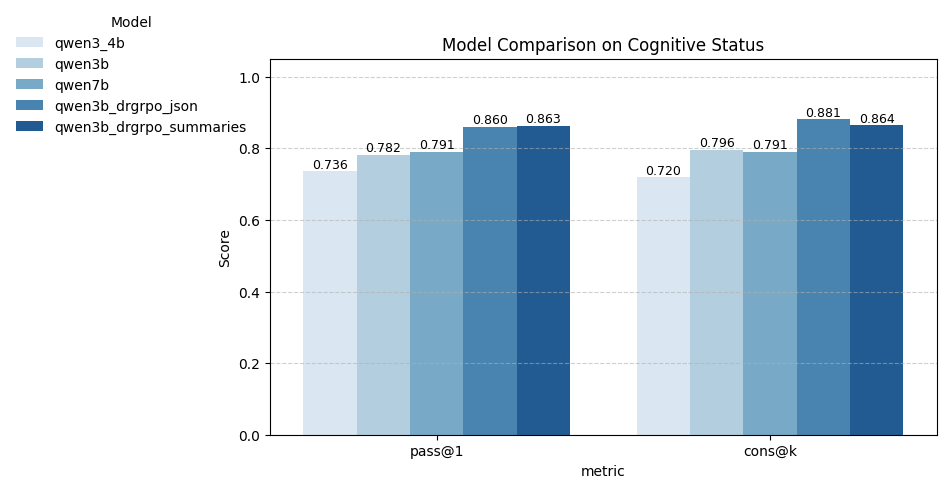

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_sorted, x='metric', y='score', hue='model', palette="Blues")

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=9)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Model Comparison on Cognitive Status")
# plt.title("Model Comparison on Neuropath")

# Move legend outside to the top left
plt.legend(title='Model', loc='upper left', bbox_to_anchor=(-0.4, 1.15), frameon=False)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
